# Attack-LLM-Judge — analysis notebook

Single source of truth for the clarity / informativeness analyses on the 714-paragraph evaluation set. Read-only against `data/paragraphs.db`.

**Judges (attack panel):** `judge_gemma9b`, `judge_llama8b`, `judge_qwen95b`.

**Methods (shared 714 human-written source paragraphs):**
- `original` — unrewritten human paragraph (baseline).
- `naive`, `lit_informed_tight`, `rubric_aware` — feedback-free single rewrite per paragraph.
- `bon_panel` — best-of-16 selection using two in-panel judges; run once per leave-one-out fold.

**Fold → judge-panel assignment** (from `attack_rewrites.judge_panel_json`):

| fold | in-panel (selectors) | held-out |
|---|---|---|
| 1 | qwen95b, llama8b | gemma9b |
| 2 | qwen95b, gemma9b | llama8b |
| 3 | llama8b, gemma9b | qwen95b |

**Gaps currently blocking full analysis** — see `DATA_REQUIREMENTS.md`. In short: GRPO-trained rewrites are not yet persisted to the DB on the 714-paragraph eval set, and LLM-generated paul_data originals have no judge scores.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/paragraphs.db').resolve()
assert DB_PATH.exists(), DB_PATH
conn = sqlite3.connect(f'file:{DB_PATH}?mode=ro', uri=True)

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Okabe-Ito colour-blind-safe palette (Wong 2011, doi:10.1038/nmeth.1618).
OKABE_ITO = {
    'black':    '#000000',
    'orange':   '#E69F00',
    'sky':      '#56B4E9',
    'green':    '#009E73',
    'yellow':   '#F0E442',
    'blue':     '#0072B2',
    'vermilion':'#D55E00',
    'purple':   '#CC79A7',
}
JUDGES = ['judge_gemma9b', 'judge_llama8b', 'judge_qwen95b']
JUDGE_COLOR = {
    'judge_gemma9b': OKABE_ITO['blue'],
    'judge_llama8b': OKABE_ITO['vermilion'],
    'judge_qwen95b': OKABE_ITO['green'],
}
METHODS = ['original', 'naive', 'lit_informed_tight', 'rubric_aware', 'bon_panel']
METHOD_LABEL = {
    'original': 'original',
    'naive': 'naive',
    'lit_informed_tight': 'lit-informed\n(tight)',
    'rubric_aware': 'rubric-aware',
    'bon_panel': 'BoN-panel\n(K=16)',
}
HELD_OUT_BY_FOLD = {1: 'judge_gemma9b', 2: 'judge_llama8b', 3: 'judge_qwen95b'}

mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#E5E5E5',
    'grid.linewidth': 0.8,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'legend.frameon': False,
    'legend.fontsize': 10,
})

## 1 — Load scores

All judge scores on the 714-paragraph eval set, both criteria, for the five methods above.

In [2]:
query = '''
-- Non-bon_panel methods: direct join to attack_judge_scores.
SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
       ajs.judge_slug, ajs.criterion, ajs.score
FROM attack_rewrites ar
JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
WHERE ar.method IN ('original', 'naive', 'lit_informed_tight', 'rubric_aware')

UNION ALL

-- bon_panel informativeness: scores are attached directly.
SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
       ajs.judge_slug, ajs.criterion, ajs.score
FROM attack_rewrites ar
JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
WHERE ar.method = 'bon_panel' AND ar.criterion = 'clarity'
  AND ajs.criterion = 'informativeness'

UNION ALL

-- bon_panel clarity: resolve via the selected bon_candidate (see DATA_REQUIREMENTS.md).
SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
       ajs.judge_slug, ajs.criterion, ajs.score
FROM attack_rewrites ar
JOIN attack_judge_scores ajs
  ON ajs.rewrite_id = json_extract(ar.config_json, '$.selected_candidate_rid')
WHERE ar.method = 'bon_panel' AND ar.criterion = 'clarity'
  AND ajs.criterion = 'clarity'
'''
scores = pd.read_sql_query(query, conn)

coverage = (scores.groupby(['criterion', 'method', 'fold', 'judge_slug'])
                  .size()
                  .unstack('judge_slug')
                  .fillna(0).astype(int))
coverage

judge_slug                      judge_gemma9b  judge_llama8b  judge_mistral7b  \
criterion       method    fold                                                  
clarity         bon_panel 1.0             714            714                0   
                          2.0             714            714                0   
                          3.0             714            714                0   
informativeness bon_panel 1.0             714            714              714   
                          2.0             714            714              714   
                          3.0             714            714              714   

judge_slug                      judge_phi35mini  judge_qwen95b  
criterion       method    fold                                  
clarity         bon_panel 1.0                 0            714  
                          2.0                 0            714  
                          3.0                 0            714  
informativeness bon_panel 1.0               714            714  
                          2.0               714            714  
                          3.0               714            714

## 2 — Judge-score distributions on human-written originals

**Full human-written corpus for the 40 most controversial propositions.** The scored-originals set in `attack_judge_scores` is exactly the top-40 propositions (by cross-writer stdev of `agreement_score` on the 4503 paul_data writer paragraphs) × ~45 writers each = **1805 human-written paragraphs**. All 1805 were scored by the full 5-judge attack panel (`gemma9b`, `llama8b`, `qwen95b`, `mistral7b`, `phi35mini`) on both clarity and informativeness. The 714-paragraph eval set used in sections 3–7 is a subset of these 1805.

The panel below also shows the controversiality ranking (stance-stdev per proposition across writers on the full paul_data corpus), confirming that the 40 scored propositions are exactly the 40 highest-variance ones.

### 2a — Controversiality ranking

All 100 UK-policy propositions in paul_data, sorted by the stdev of human-rated `agreement_score` across the ~45 writer paragraphs per proposition. Red bars are the 40 propositions whose writer paragraphs were scored by the attack-judge panel — and they line up exactly with the top-40 cutoff.

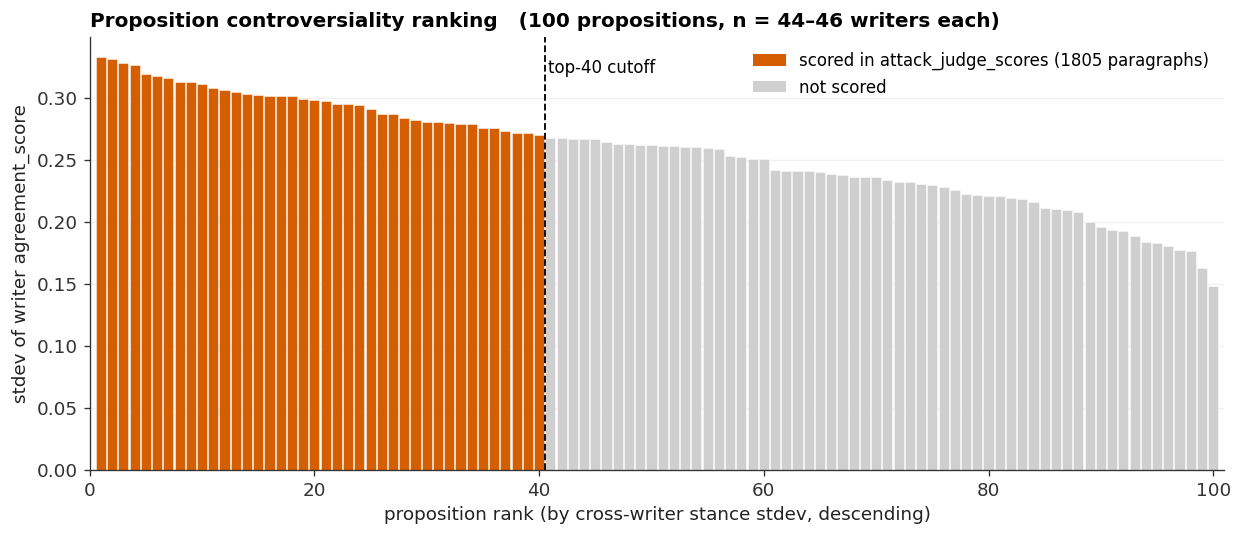

In [3]:
# Rank propositions by across-writer stance variance (controversiality).
_docs = pd.read_csv('../paul_data/prepared/documents.csv',
                    usecols=['document_id', 'proposition_id', 'paragraph_type',
                             'agreement_score'])
_props = pd.read_csv('../paul_data/main_phase_1/propositions.csv')

_writers_full = _docs[_docs['paragraph_type'] == 'writer']
controversy = (_writers_full.groupby('proposition_id')['agreement_score']
               .agg(stance_mean='mean', stance_std='std', n_writers='count')
               .reset_index()
               .merge(_props, on='proposition_id', how='left')
               .sort_values('stance_std', ascending=False)
               .reset_index(drop=True))
controversy['rank'] = controversy.index + 1

# Which propositions are actually in the scored corpus?
_scored_ids = pd.read_sql_query(
    "SELECT DISTINCT source_doc_id FROM attack_rewrites WHERE method='original'",
    conn)['source_doc_id']
_scored_props = set(_docs[_docs['document_id'].isin(_scored_ids)]['proposition_id'])
controversy['in_scored_corpus'] = controversy['proposition_id'].isin(_scored_props)

fig, ax = plt.subplots(figsize=(10.5, 4.6))
bar_color = np.where(controversy['in_scored_corpus'],
                     OKABE_ITO['vermilion'], '#CFCFCF')
ax.bar(controversy['rank'], controversy['stance_std'], 0.9,
       color=bar_color, edgecolor='white', linewidth=0.3)
ax.axvline(40.5, color=OKABE_ITO['black'], linestyle='--', linewidth=1.1)
ax.text(40.8, ax.get_ylim()[1] * 0.95, 'top-40 cutoff',
        ha='left', va='top', fontsize=10, color=OKABE_ITO['black'])

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=OKABE_ITO['vermilion'], label='scored in attack_judge_scores (1805 paragraphs)'),
    Patch(facecolor='#CFCFCF', label='not scored'),
], loc='upper right', frameon=False, fontsize=10)
ax.set_xlabel('proposition rank (by cross-writer stance stdev, descending)')
ax.set_ylabel('stdev of writer agreement_score')
ax.set_title('Proposition controversiality ranking   (100 propositions, n = 44–46 writers each)',
             loc='left')
ax.grid(axis='y', linestyle='-', alpha=0.5)
ax.grid(axis='x', visible=False)
ax.set_xlim(0, 101)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1a_controversy_ranking.png')
plt.show()

Human originals scored: 1805 paragraphs across 40 propositions


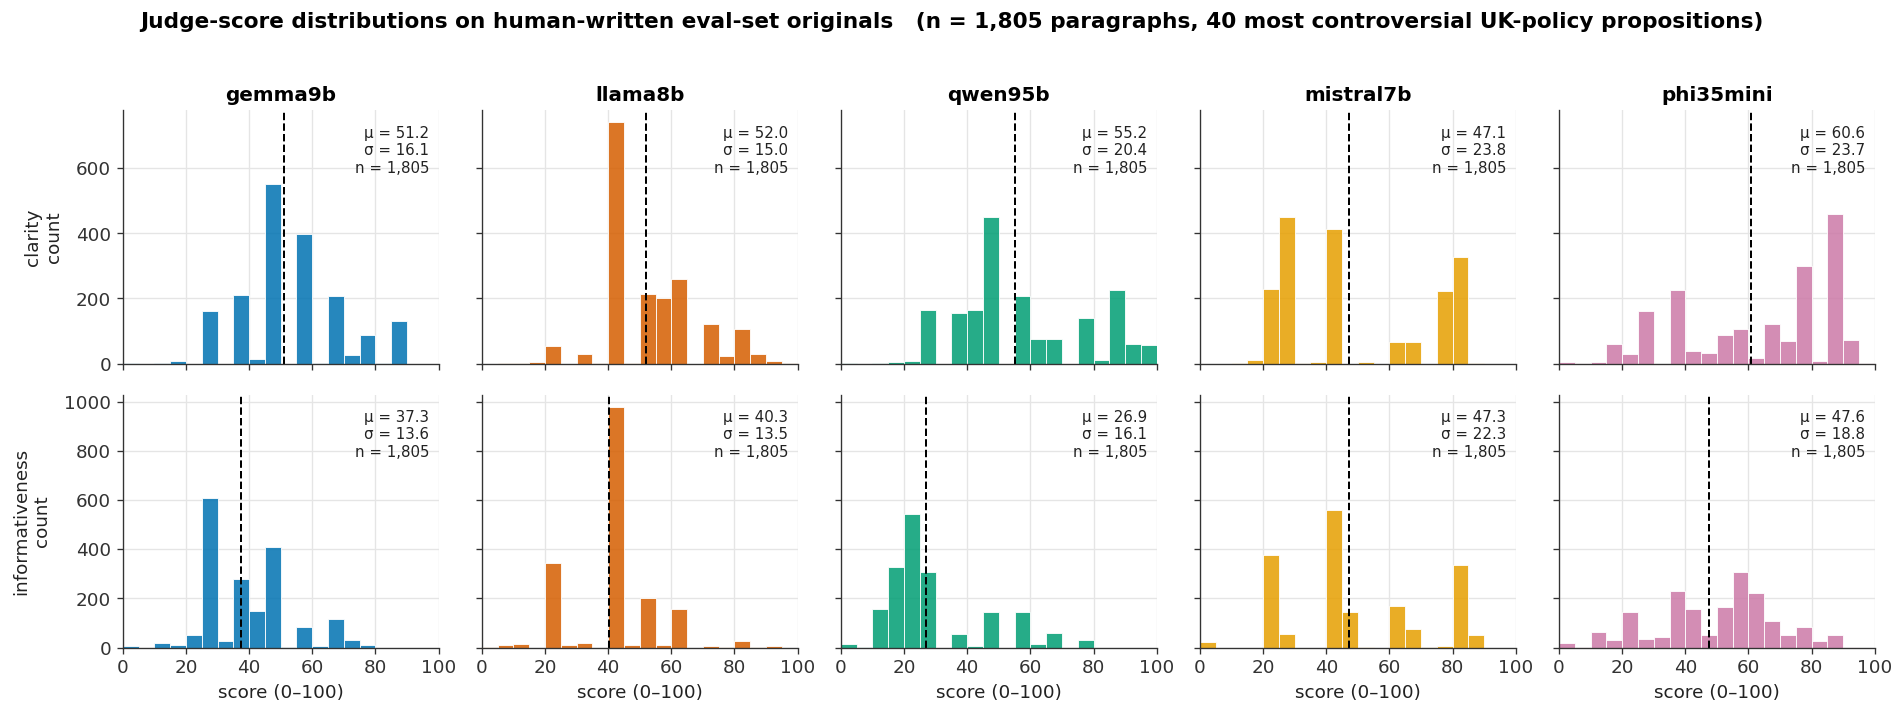

In [4]:
# Load originals for all 5 attack judges (full 1805-paragraph corpus).
ALL_5_JUDGES = ['judge_gemma9b', 'judge_llama8b', 'judge_qwen95b',
                'judge_mistral7b', 'judge_phi35mini']
JUDGE5_COLOR = {
    'judge_gemma9b':   OKABE_ITO['blue'],
    'judge_llama8b':   OKABE_ITO['vermilion'],
    'judge_qwen95b':   OKABE_ITO['green'],
    'judge_mistral7b': OKABE_ITO['orange'],
    'judge_phi35mini': OKABE_ITO['purple'],
}

orig_full = pd.read_sql_query(f'''
  SELECT ar.source_doc_id, ajs.judge_slug, ajs.criterion, ajs.score
  FROM attack_rewrites ar
  JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
  WHERE ar.method = 'original'
    AND ajs.judge_slug IN ({','.join(f"'{j}'" for j in ALL_5_JUDGES)})
''', conn)

_n_paragraphs = orig_full['source_doc_id'].nunique()
_n_props = (orig_full[['source_doc_id']]
            .merge(_docs[['document_id', 'proposition_id']],
                   left_on='source_doc_id', right_on='document_id')
            ['proposition_id'].nunique())
print(f'Human originals scored: {_n_paragraphs} paragraphs across {_n_props} propositions')

CRITERIA2 = ['clarity', 'informativeness']
BINS = np.arange(0, 105, 5)

fig, axes = plt.subplots(len(CRITERIA2), len(ALL_5_JUDGES),
                         figsize=(16, 5.8), sharex=True, sharey='row')

for i, criterion in enumerate(CRITERIA2):
    for j, judge in enumerate(ALL_5_JUDGES):
        ax = axes[i, j]
        vals = orig_full.query('criterion == @criterion and judge_slug == @judge')['score']
        ax.hist(vals, bins=BINS, color=JUDGE5_COLOR[judge], alpha=0.85,
                edgecolor='white', linewidth=0.6)
        ax.axvline(vals.mean(), color=OKABE_ITO['black'], linestyle='--', linewidth=1.2)
        ax.text(0.97, 0.94,
                f'μ = {vals.mean():.1f}\nσ = {vals.std(ddof=1):.1f}\nn = {len(vals):,}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                color='#222222')
        if i == 0:
            ax.set_title(judge.replace('judge_', ''))
        if i == len(CRITERIA2) - 1:
            ax.set_xlabel('score (0–100)')
        if j == 0:
            ax.set_ylabel(f'{criterion}\ncount', rotation=90, labelpad=8)
        ax.set_xlim(0, 100)

fig.suptitle(
    f'Judge-score distributions on human-written eval-set originals   '
    f'(n = {_n_paragraphs:,} paragraphs, 40 most controversial UK-policy propositions)',
    y=1.02, fontsize=13, fontweight='semibold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig1_distributions_originals.png')
plt.show()

## 3 — Clarity results: mean score by method × judge

`bon_panel` pooled across folds (see section 6 for the in-panel / held-out split).

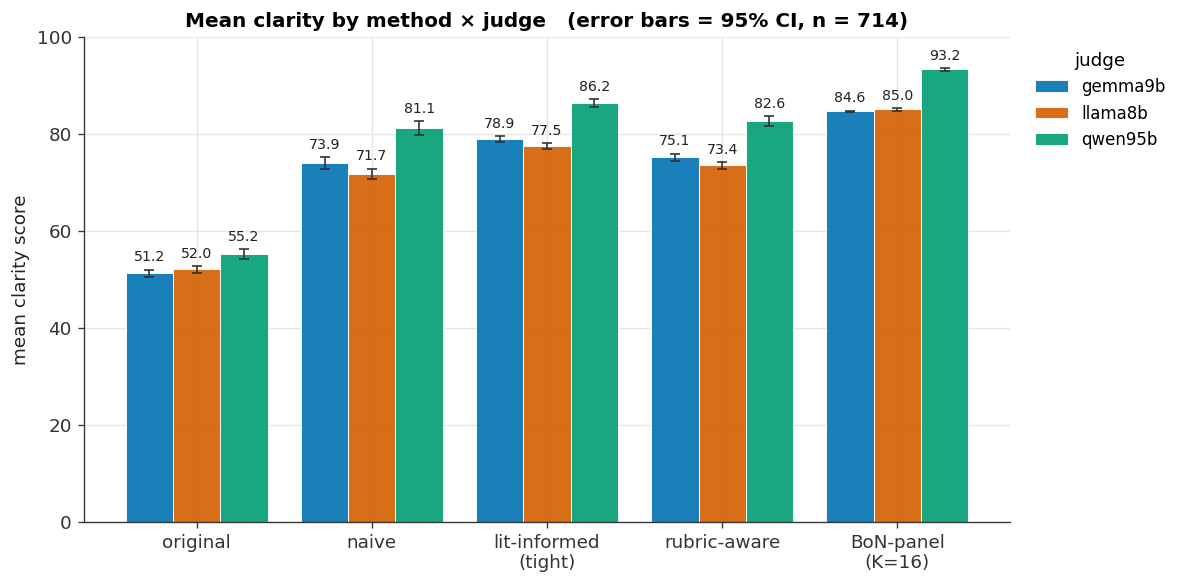

In [5]:
clarity = scores[scores['criterion'] == 'clarity']

agg = (clarity.groupby(['method', 'judge_slug'])['score']
       .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)))
       .reset_index())
agg['ci'] = 1.96 * agg['sem']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(METHODS))
width = 0.27
for i, judge in enumerate(JUDGES):
    sub = agg[agg['judge_slug'] == judge].set_index('method').reindex(METHODS)
    bars = ax.bar(x + (i - 1) * width, sub['mean'], width,
                  yerr=sub['ci'], capsize=3,
                  label=judge.replace('judge_', ''),
                  color=JUDGE_COLOR[judge], alpha=0.9,
                  edgecolor='white', linewidth=0.6,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    for bar, mean, ci in zip(bars, sub['mean'], sub['ci']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 1.2,
                f'{mean:.1f}', ha='center', va='bottom', fontsize=8.5,
                color='#222222')

ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABEL[m] for m in METHODS])
ax.set_ylabel('mean clarity score')
ax.set_ylim(0, 100)
ax.set_title('Mean clarity by method × judge   (error bars = 95% CI, n = 714)')
ax.legend(title='judge', loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_clarity_means.png')
plt.show()

## 4 — Paired clarity gain over `original`

Within-paragraph differences: `score(method) − score(original)` per (paragraph, judge). Paired CIs use the per-paragraph delta SE.

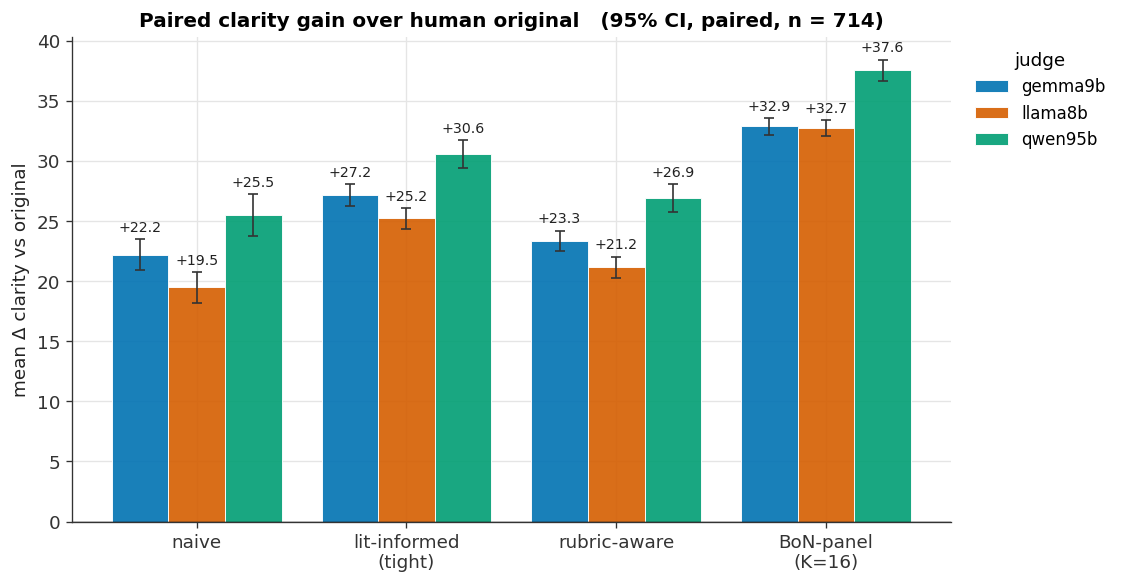

In [6]:
orig = (clarity[clarity['method'] == 'original']
        .groupby(['source_doc_id', 'judge_slug'])['score']
        .mean().rename('orig_score').reset_index())

pair = clarity[clarity['method'] != 'original'].merge(orig, on=['source_doc_id', 'judge_slug'])
pair['delta'] = pair['score'] - pair['orig_score']

delta_agg = (pair.groupby(['method', 'judge_slug'])['delta']
             .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)))
             .reset_index())
delta_agg['ci'] = 1.96 * delta_agg['sem']

methods_nb = [m for m in METHODS if m != 'original']
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(methods_nb))
width = 0.27
for i, judge in enumerate(JUDGES):
    sub = delta_agg[delta_agg['judge_slug'] == judge].set_index('method').reindex(methods_nb)
    bars = ax.bar(x + (i - 1) * width, sub['mean'], width,
                  yerr=sub['ci'], capsize=3,
                  label=judge.replace('judge_', ''),
                  color=JUDGE_COLOR[judge], alpha=0.9,
                  edgecolor='white', linewidth=0.6,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    for bar, mean, ci in zip(bars, sub['mean'], sub['ci']):
        if mean >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 0.4,
                    f'{mean:+.1f}', ha='center', va='bottom', fontsize=8.5, color='#222222')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - ci - 0.4,
                    f'{mean:+.1f}', ha='center', va='top', fontsize=8.5, color='#222222')

ax.axhline(0, color=OKABE_ITO['black'], linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABEL[m] for m in methods_nb])
ax.set_ylabel('mean Δ clarity vs original')
ax.set_title('Paired clarity gain over human original   (95% CI, paired, n = 714)')
ax.legend(title='judge', loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_clarity_deltas.png')
plt.show()

## 5 — Clarity score distribution by method, faceted by judge

Boxes: IQR. Whiskers: 1.5×IQR. Diamonds: mean.

/tmp/ipykernel_1039011/2450747871.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1039011/2450747871.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_1039011/2450747871.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


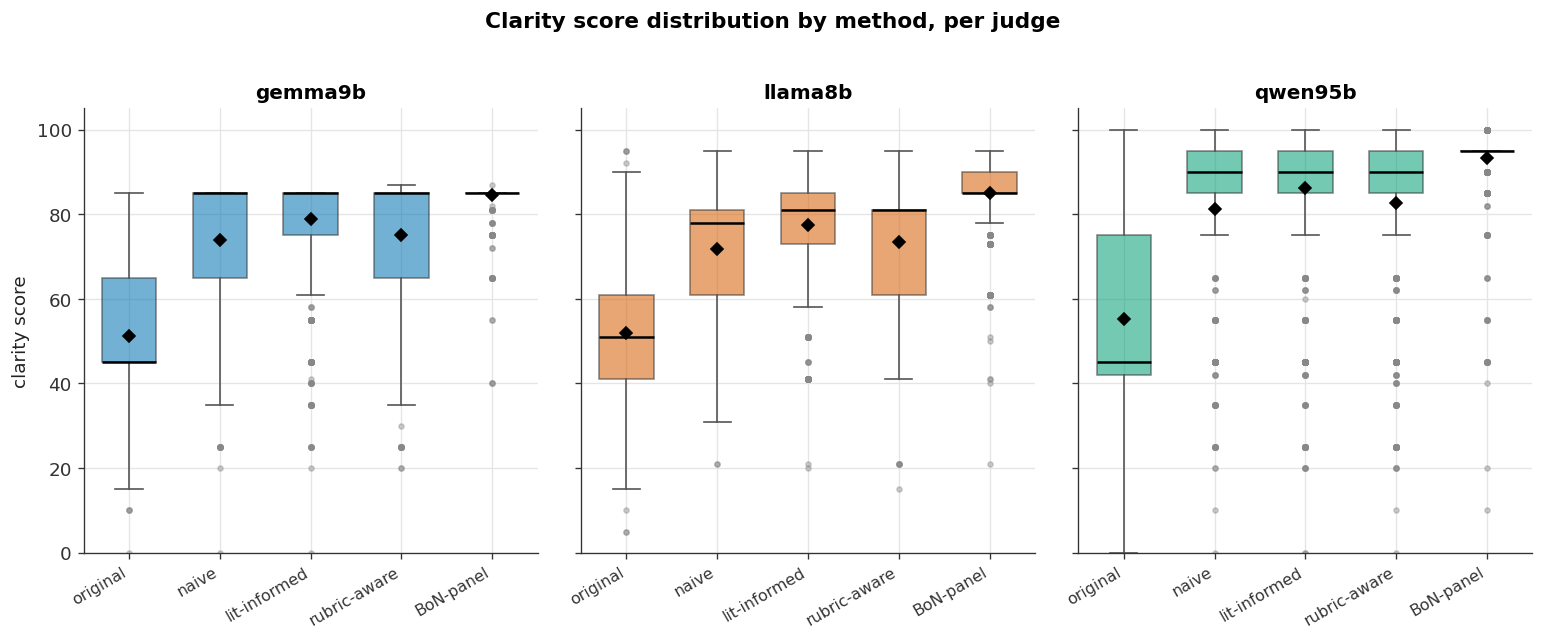

In [7]:
SHORT_LABELS = {
    'original': 'original',
    'naive': 'naive',
    'lit_informed_tight': 'lit-informed',
    'rubric_aware': 'rubric-aware',
    'bon_panel': 'BoN-panel',
}

fig, axes = plt.subplots(1, len(JUDGES), figsize=(13, 5.2), sharey=True)
for ax, judge in zip(axes, JUDGES):
    data = [clarity.query('method == @m and judge_slug == @judge')['score'].values for m in METHODS]
    bp = ax.boxplot(
        data, labels=[SHORT_LABELS[m] for m in METHODS],
        showmeans=True,
        meanprops={'marker': 'D', 'markerfacecolor': OKABE_ITO['black'],
                    'markeredgecolor': OKABE_ITO['black'], 'markersize': 5},
        medianprops={'color': OKABE_ITO['black'], 'linewidth': 1.5},
        whiskerprops={'color': '#555555'},
        capprops={'color': '#555555'},
        flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': '#888888',
                     'markeredgecolor': '#888888', 'alpha': 0.4},
        patch_artist=True, widths=0.6,
    )
    for patch in bp['boxes']:
        patch.set_facecolor(JUDGE_COLOR[judge])
        patch.set_alpha(0.55)
        patch.set_edgecolor('#333333')
    ax.set_title(judge.replace('judge_', ''))
    ax.set_ylim(0, 105)
    if ax is axes[0]:
        ax.set_ylabel('clarity score')
    ax.tick_params(axis='x', labelsize=9.5)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

fig.suptitle('Clarity score distribution by method, per judge',
             y=1.02, fontsize=13, fontweight='semibold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig4_clarity_distributions.png')
plt.show()

## 6 — `bon_panel` cross-judge transfer

Per judge, the mean `bon_panel` score partitioned by the judge's role in the fold. 'in-panel' pools the two folds where this judge was a selector; 'held-out' uses the one fold where it was not. Dashed line = `original` mean for the same judge.

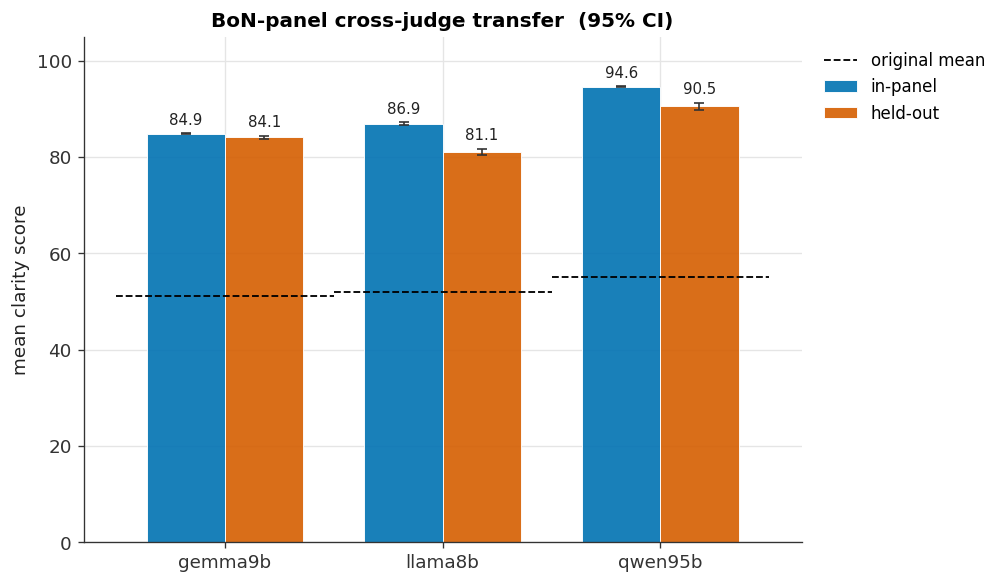

In [8]:
bp_df = clarity[clarity['method'] == 'bon_panel'].copy()
bp_df['role'] = np.where(
    bp_df['judge_slug'] == bp_df['fold'].map(HELD_OUT_BY_FOLD),
    'held-out', 'in-panel',
)

transfer = (bp_df.groupby(['judge_slug', 'role'])['score']
            .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)))
            .reset_index())
transfer['ci'] = 1.96 * transfer['sem']

orig_means = (clarity[clarity['method'] == 'original']
              .groupby('judge_slug')['score'].mean())

ROLE_COLOR = {'in-panel': OKABE_ITO['blue'], 'held-out': OKABE_ITO['vermilion']}

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(JUDGES))
width = 0.36
for i, role in enumerate(['in-panel', 'held-out']):
    sub = transfer[transfer['role'] == role].set_index('judge_slug').reindex(JUDGES)
    bars = ax.bar(x + (i - 0.5) * width, sub['mean'], width,
                  yerr=sub['ci'], capsize=3,
                  label=role, color=ROLE_COLOR[role], alpha=0.9,
                  edgecolor='white', linewidth=0.6,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    for bar, mean, ci in zip(bars, sub['mean'], sub['ci']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + ci + 1.2,
                f'{mean:.1f}', ha='center', va='bottom', fontsize=9, color='#222222')

for i, judge in enumerate(JUDGES):
    ax.hlines(orig_means[judge], x[i] - 0.5, x[i] + 0.5,
              linestyle='--', color=OKABE_ITO['black'], linewidth=1.1)

ax.plot([], [], linestyle='--', color=OKABE_ITO['black'], linewidth=1.1,
        label='original mean')
ax.set_xticks(x)
ax.set_xticklabels([j.replace('judge_', '') for j in JUDGES])
ax.set_ylabel('mean clarity score')
ax.set_ylim(0, 105)
ax.set_title('BoN-panel cross-judge transfer  (95% CI)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig5_bon_panel_transfer.png')
plt.show()

## 7 — Attack-method improvement analysis

Three questions across the full 5-judge panel (`gemma9b`, `llama8b`, `qwen95b`, `mistral7b`, `phi35mini`) and both criteria:

1. **Feedback-free methods** (`naive`, `lit_informed_tight`, `rubric_aware`): paired improvement vs `original`, pooled over judges, split by method × criterion.
2. **Feedback-using methods** (`icir`, `bon_panel`, `grpo_400step`): paired improvement vs `original`, pooled over folds, split by method × criterion × in-sample/out-of-sample judge role.
3. **Agreement-score shift and stance flip**: rewrite-vs-original agreement_score drift; % of paragraphs whose stance flips across the 0.4 / 0.6 bands (paragraphs with original in (0.4, 0.6) excluded).

**Judge roles per fold** (in-panel = used as selector/feedback source; out-of-sample = all other judges including held-out attack judge and the two never-seen judges `mistral7b`, `phi35mini`):

| fold | in-panel | held-out attack | always out-of-sample |
|---|---|---|---|
| 1 | qwen95b, llama8b | gemma9b | mistral7b, phi35mini |
| 2 | qwen95b, gemma9b | llama8b | mistral7b, phi35mini |
| 3 | llama8b, gemma9b | qwen95b | mistral7b, phi35mini |

In [9]:
FEEDBACK_FREE = ['naive', 'lit_informed_tight', 'rubric_aware']
FEEDBACK_USING = ['icir', 'bon_panel', 'grpo_400step']
ALL_METHODS = FEEDBACK_FREE + FEEDBACK_USING
ALL_JUDGES = ['judge_gemma9b', 'judge_llama8b', 'judge_qwen95b', 'judge_mistral7b', 'judge_phi35mini']
IN_PANEL_BY_FOLD = {
    1: {'judge_qwen95b', 'judge_llama8b'},
    2: {'judge_qwen95b', 'judge_gemma9b'},
    3: {'judge_llama8b', 'judge_gemma9b'},
}

method_list = ','.join(f"'{m}'" for m in ALL_METHODS)
judge_list = ','.join(f"'{j}'" for j in ALL_JUDGES)

orig_scores_all = pd.read_sql_query(f'''
  SELECT ar.source_doc_id, ajs.judge_slug, ajs.criterion, ajs.score AS orig_score
  FROM attack_rewrites ar
  JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
  WHERE ar.method = 'original'
    AND ar.source_doc_id IN (SELECT DISTINCT source_doc_id FROM attack_rewrites WHERE method != 'original')
    AND ajs.judge_slug IN ({judge_list})
''', conn)

rewrite_scores = pd.read_sql_query(f'''
  SELECT ar.rewrite_id, ar.source_doc_id, ar.method, ar.fold,
         ar.criterion AS rewrite_criterion,
         ajs.judge_slug, ajs.score
  FROM attack_rewrites ar
  JOIN attack_judge_scores ajs ON ajs.rewrite_id = ar.rewrite_id
  WHERE ar.method IN ({method_list})
    AND ajs.judge_slug IN ({judge_list})
    AND ajs.criterion = ar.criterion
''', conn)

deltas = rewrite_scores.merge(
    orig_scores_all.rename(columns={'criterion': 'rewrite_criterion'}),
    on=['source_doc_id', 'judge_slug', 'rewrite_criterion'], how='left',
)
assert deltas['orig_score'].notna().all()
deltas['delta'] = deltas['score'] - deltas['orig_score']
print(f'rows: {len(deltas):,}  methods: {sorted(deltas.method.unique())}  criteria: {sorted(deltas.rewrite_criterion.unique())}')

rows: 82,110  methods: ['bon_panel', 'grpo_400step', 'icir', 'lit_informed_tight', 'naive', 'rubric_aware']  criteria: ['clarity', 'informativeness']


In [10]:
# --- Plotting helpers for section 7 ---
METHOD_ORDER = ['naive', 'rubric_aware', 'lit_informed_tight', 'icir', 'bon_panel', 'grpo_400step']
METHOD_TICK = {
    'naive': 'naive',
    'rubric_aware': 'rubric-aware',
    'lit_informed_tight': 'lit-informed\n(tight)',
    'icir': 'ICIR',
    'bon_panel': 'BoN-panel',
    'grpo_400step': 'GRPO\n(400 step)',
}
CRITERION_COLOR = {
    'clarity': OKABE_ITO['blue'],
    'informativeness': OKABE_ITO['vermilion'],
}
ROLE_COLOR = {
    'in_sample': OKABE_ITO['blue'],
    'out_of_sample': OKABE_ITO['vermilion'],
    'oos_heldout_attack': OKABE_ITO['orange'],
    'oos_never_seen': OKABE_ITO['green'],
}
ROLE_LABEL = {
    'in_sample': 'in-sample (selectors)',
    'out_of_sample': 'out-of-sample',
    'oos_heldout_attack': 'held-out attack judge',
    'oos_never_seen': 'never-seen (mistral / phi)',
}


def _style_bar_axes(ax, xlabel=None, ylabel=None, title=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    ax.grid(axis='y', linestyle='-', alpha=0.5)
    ax.grid(axis='x', visible=False)
    ax.axhline(0, color=OKABE_ITO['black'], linewidth=0.8)


def _annotate_bars(ax, bars, values, cis=None, fmt='{:+.1f}', fontsize=8.5, pad=0.4):
    for i, bar in enumerate(bars):
        h = bar.get_height()
        ci = cis[i] if cis is not None else 0
        if h >= 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + ci + pad,
                    fmt.format(values[i]), ha='center', va='bottom',
                    fontsize=fontsize, color='#222222')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, h - ci - pad,
                    fmt.format(values[i]), ha='center', va='top',
                    fontsize=fontsize, color='#222222')


### 7.1 — Feedback-free methods: paired improvement vs original

Pooled across all 5 judges and 714 paragraphs. `naive` has clarity-targeted rewrites only, so no informativeness row. 95% CIs treat each (paragraph, judge) delta as an independent observation — clustered SEs would be wider but the ranking is unaffected.

In [11]:
ff = deltas[deltas['method'].isin(FEEDBACK_FREE)]
q1 = (ff.groupby(['method', 'rewrite_criterion'])['delta']
        .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n='count')
        .reset_index()
        .rename(columns={'rewrite_criterion': 'criterion'}))
q1['ci95'] = 1.96 * q1['sem']
q1 = q1[['method', 'criterion', 'mean', 'ci95', 'n']]
q1 = q1.sort_values(['criterion', 'mean'], ascending=[True, False]).reset_index(drop=True)
q1.round(2)

,method,criterion,mean,ci95,n
0,lit_informed_tight,clarity,27.06,0.69,3570
1,rubric_aware,clarity,23.77,0.68,3570
2,naive,clarity,22.52,0.70,3570
3,lit_informed_tight,informativeness,10.22,0.60,3570
4,rubric_aware,informativeness,6.68,0.53,3570


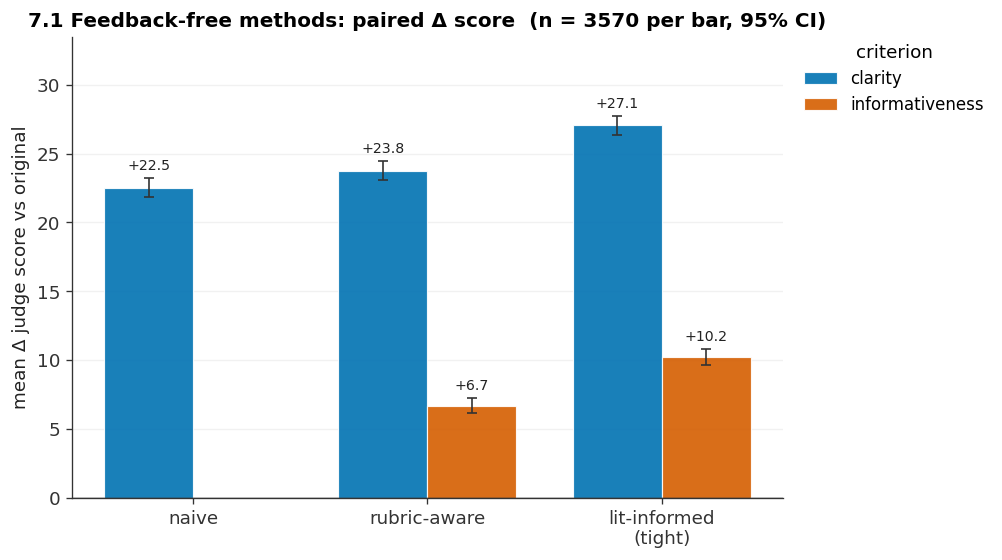

In [12]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
criteria = ['clarity', 'informativeness']

fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(methods_ff))
width = 0.38
for i, crit in enumerate(criteria):
    sub = q1[q1['criterion'] == crit].set_index('method').reindex(methods_ff)
    means = sub['mean'].values
    cis = sub['ci95'].values
    bars = ax.bar(x + (i - 0.5) * width, means, width,
                  yerr=cis, capsize=3,
                  label=crit, color=CRITERION_COLOR[crit], alpha=0.9,
                  edgecolor='white', linewidth=0.7,
                  error_kw={'ecolor': '#333333', 'elinewidth': 1})
    valid = ~np.isnan(means)
    _annotate_bars(ax, [b for b, v in zip(bars, valid) if v],
                   means[valid], cis[valid], fmt='{:+.1f}')

ax.set_xticks(x)
ax.set_xticklabels([METHOD_TICK[m] for m in methods_ff])
_style_bar_axes(ax,
                ylabel='mean Δ judge score vs original',
                title='7.1 Feedback-free methods: paired Δ score  (n = 3570 per bar, 95% CI)')
ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
ax.legend(title='criterion', loc='upper left',
          bbox_to_anchor=(1.02, 1.0), frameon=False, borderaxespad=0)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig7_1_feedback_free_delta.png')
plt.show()

### 7.2 — Feedback-using methods: paired improvement split by judge role

Each (paragraph, fold, judge) observation is tagged `in_sample` if the judge was in that fold's in-panel selector set, else `out_of_sample`. Pooled over folds.

For finer-grained inspection, a secondary split further separates out-of-sample into the held-out attack judge vs. the two never-seen judges (`mistral7b`, `phi35mini`).

In [13]:
fu = deltas[deltas['method'].isin(FEEDBACK_USING)].copy()
fu['in_panel'] = fu.apply(
    lambda r: r['judge_slug'] in IN_PANEL_BY_FOLD[int(r['fold'])], axis=1)
fu['role'] = np.where(fu['in_panel'], 'in_sample', 'out_of_sample')

q2 = (fu.groupby(['method', 'rewrite_criterion', 'role'])['delta']
        .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n='count')
        .reset_index()
        .rename(columns={'rewrite_criterion': 'criterion'}))
q2['ci95'] = 1.96 * q2['sem']
q2 = q2[['method', 'criterion', 'role', 'mean', 'ci95', 'n']]
q2 = q2.sort_values(['criterion', 'method', 'role']).reset_index(drop=True)
q2.round(2)

,method,criterion,role,mean,ci95,n
0,bon_panel,clarity,in_sample,35.04,0.53,4284
1,bon_panel,clarity,out_of_sample,30.59,0.54,6426
2,grpo_400step,clarity,in_sample,35.26,0.53,4284
3,grpo_400step,clarity,out_of_sample,32.62,0.54,6426
4,icir,clarity,in_sample,26.89,0.59,4284
5,icir,clarity,out_of_sample,26.65,0.55,6426
6,bon_panel,informativeness,in_sample,25.76,0.53,4284
7,bon_panel,informativeness,out_of_sample,24.82,0.53,6426
8,grpo_400step,informativeness,in_sample,15.99,0.52,4284
9,grpo_400step,informativeness,out_of_sample,23.40,0.50,6426


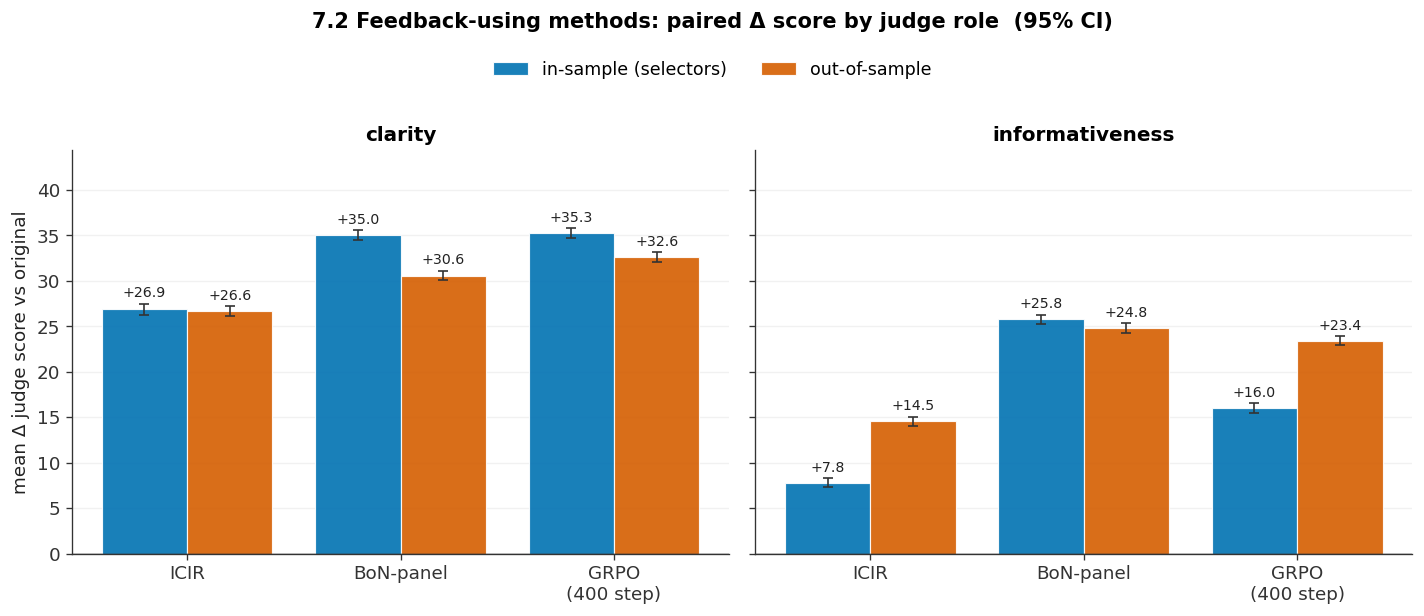

In [14]:
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']
roles = ['in_sample', 'out_of_sample']

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), sharey=True)
role_handles = []
for ax, crit in zip(axes, criteria):
    x = np.arange(len(methods_fu))
    width = 0.4
    for i, role in enumerate(roles):
        sub = (q2[(q2['criterion'] == crit) & (q2['role'] == role)]
               .set_index('method').reindex(methods_fu))
        means = sub['mean'].values
        cis = sub['ci95'].values
        bars = ax.bar(x + (i - 0.5) * width, means, width,
                      yerr=cis, capsize=3,
                      label=ROLE_LABEL[role], color=ROLE_COLOR[role], alpha=0.9,
                      edgecolor='white', linewidth=0.7,
                      error_kw={'ecolor': '#333333', 'elinewidth': 1})
        _annotate_bars(ax, bars, means, cis, fmt='{:+.1f}')
        if ax is axes[0]:
            role_handles.append(bars)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
    _style_bar_axes(ax,
                    ylabel='mean Δ judge score vs original' if ax is axes[0] else None,
                    title=crit)

# shared y-axis with headroom for legend above bars
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.18)

fig.legend([h for h in role_handles], [ROLE_LABEL[r] for r in roles],
           loc='upper center', bbox_to_anchor=(0.5, 0.965),
           ncol=2, frameon=False, fontsize=10.5)
fig.suptitle('7.2 Feedback-using methods: paired Δ score by judge role  (95% CI)',
             y=1.02, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'fig7_2_feedback_using_delta.png')
plt.show()

In [15]:
ATTACK_PANEL = {'judge_gemma9b', 'judge_llama8b', 'judge_qwen95b'}

def role_fine(r):
    if r['judge_slug'] in IN_PANEL_BY_FOLD[int(r['fold'])]:
        return 'in_sample'
    if r['judge_slug'] in ATTACK_PANEL:
        return 'oos_heldout_attack'
    return 'oos_never_seen'

fu['role_fine'] = fu.apply(role_fine, axis=1)
q2b = (fu.groupby(['method', 'rewrite_criterion', 'role_fine'])['delta']
         .agg(mean='mean', sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n='count')
         .reset_index()
         .rename(columns={'rewrite_criterion': 'criterion'}))
q2b['ci95'] = 1.96 * q2b['sem']
ROLE_ORDER = {'in_sample': 0, 'oos_heldout_attack': 1, 'oos_never_seen': 2}
q2b['_role_ord'] = q2b['role_fine'].map(ROLE_ORDER)
q2b = (q2b.sort_values(['criterion', 'method', '_role_ord'])
          .drop(columns='_role_ord')
          .reset_index(drop=True))
q2b = q2b[['method', 'criterion', 'role_fine', 'mean', 'ci95', 'n']]
q2b.round(2)

,method,criterion,role_fine,mean,ci95,n
0,bon_panel,clarity,in_sample,35.04,0.53,4284
1,bon_panel,clarity,oos_heldout_attack,31.91,0.78,2142
2,bon_panel,clarity,oos_never_seen,29.93,0.71,4284
3,grpo_400step,clarity,in_sample,35.26,0.53,4284
4,grpo_400step,clarity,oos_heldout_attack,35.14,0.76,2142
5,grpo_400step,clarity,oos_never_seen,31.35,0.71,4284
6,icir,clarity,in_sample,26.89,0.59,4284
7,icir,clarity,oos_heldout_attack,27.01,0.83,2142
8,icir,clarity,oos_never_seen,26.47,0.71,4284
9,bon_panel,informativeness,in_sample,25.76,0.53,4284


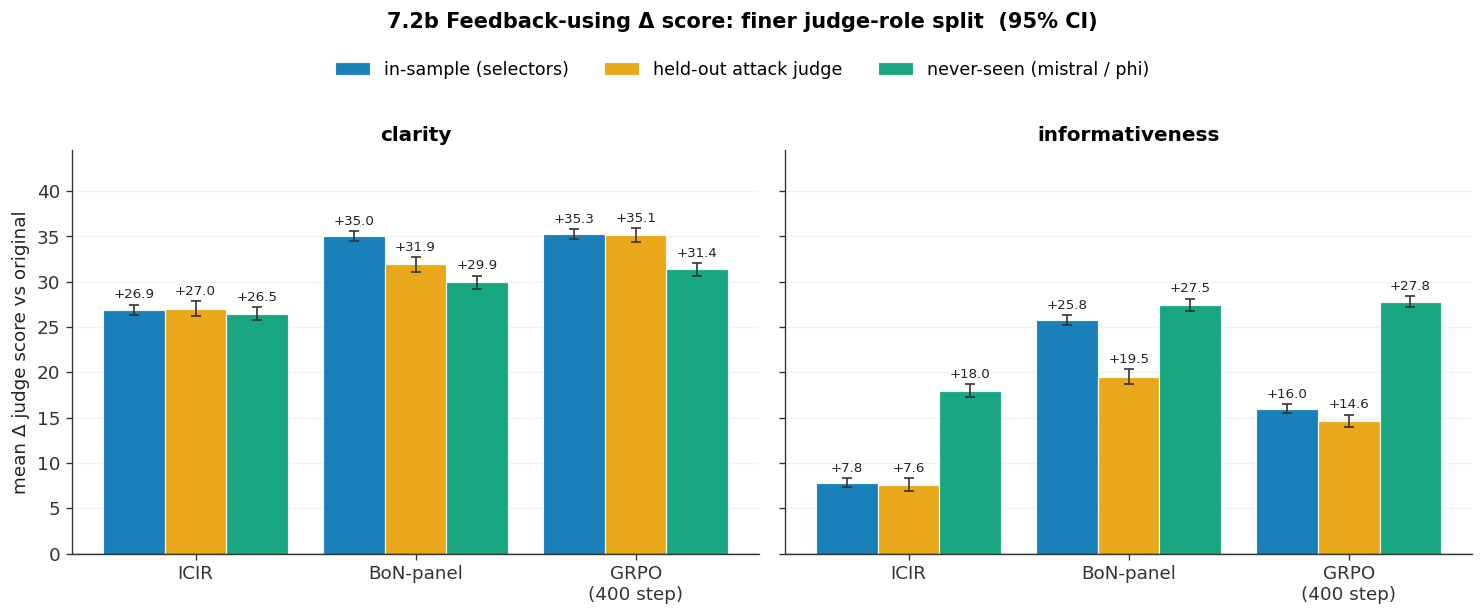

In [16]:
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']
roles_fine = ['in_sample', 'oos_heldout_attack', 'oos_never_seen']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), sharey=True)
handles_by_role = {}
for ax, crit in zip(axes, criteria):
    x = np.arange(len(methods_fu))
    width = 0.28
    for i, role in enumerate(roles_fine):
        sub = (q2b[(q2b['criterion'] == crit) & (q2b['role_fine'] == role)]
               .set_index('method').reindex(methods_fu))
        means = sub['mean'].values
        cis = sub['ci95'].values
        bars = ax.bar(x + (i - 1) * width, means, width,
                      yerr=cis, capsize=3,
                      label=ROLE_LABEL[role], color=ROLE_COLOR[role], alpha=0.9,
                      edgecolor='white', linewidth=0.7,
                      error_kw={'ecolor': '#333333', 'elinewidth': 1})
        _annotate_bars(ax, bars, means, cis, fmt='{:+.1f}', fontsize=8)
        if ax is axes[0]:
            handles_by_role[role] = bars
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
    _style_bar_axes(ax,
                    ylabel='mean Δ judge score vs original' if ax is axes[0] else None,
                    title=crit)

axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.18)

fig.legend([handles_by_role[r] for r in roles_fine],
           [ROLE_LABEL[r] for r in roles_fine],
           loc='upper center', bbox_to_anchor=(0.5, 0.965),
           ncol=3, frameon=False, fontsize=10.5)
fig.suptitle('7.2b Feedback-using Δ score: finer judge-role split  (95% CI)',
             y=1.02, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'fig7_2b_feedback_using_delta_fine.png')
plt.show()

### 7.3 — Agreement-score shift and stance flip

`agreement_score` is the DeBERTa-v3-base regressor output on [0, 1], where 0 = disagrees with the proposition and 1 = agrees. Shift = `agreement(rewrite) − agreement(original)` for the same source paragraph.

**Flip criterion** (tightened): paragraph is *flipped* if the original score is ≤ 0.25 and the rewrite is ≥ 0.75, or vice versa (strong stance → strong opposite stance). Paragraphs whose original lies strictly between 0.25 and 0.75 are excluded because their original stance is too moderate to flip meaningfully. Of the 714 eval paragraphs: 246 have an original ≤ 0.25 (clear anti), 268 have ≥ 0.75 (clear pro), and 200 fall in the excluded middle.

In [17]:
orig_agree = pd.read_sql_query('''
  SELECT ar.source_doc_id, aas.score AS orig_agree
  FROM attack_rewrites ar
  JOIN attack_agreement_scores aas ON aas.rewrite_id = ar.rewrite_id
  WHERE ar.method = 'original'
    AND ar.source_doc_id IN (SELECT DISTINCT source_doc_id FROM attack_rewrites WHERE method != 'original')
''', conn)

rew_agree = pd.read_sql_query(f'''
  SELECT ar.source_doc_id, ar.method, ar.fold,
         ar.criterion AS rewrite_criterion,
         aas.score AS rewrite_agree
  FROM attack_rewrites ar
  JOIN attack_agreement_scores aas ON aas.rewrite_id = ar.rewrite_id
  WHERE ar.method IN ({method_list})
''', conn)

# Attach proposition_leaning from paul_data (left / right / neither).
_docs = pd.read_csv('../paul_data/prepared/documents.csv',
                    usecols=['document_id', 'proposition_id'])
_props = pd.read_csv('../paul_data/main_phase_1/propositions.csv',
                     usecols=['proposition_id', 'proposition_leaning'])
_leaning = (_docs.merge(_props, on='proposition_id', how='left')
                 [['document_id', 'proposition_leaning']]
                 .rename(columns={'document_id': 'source_doc_id'}))

agree = (rew_agree.merge(orig_agree, on='source_doc_id', how='left')
                  .merge(_leaning, on='source_doc_id', how='left'))
assert agree['orig_agree'].notna().all()
assert agree['proposition_leaning'].notna().all()
agree['shift'] = agree['rewrite_agree'] - agree['orig_agree']
agree['abs_shift'] = agree['shift'].abs()

FLIP_LOW, FLIP_HIGH = 0.25, 0.75

def classify(orig, new):
    if FLIP_LOW < orig < FLIP_HIGH:
        return 'excluded'
    if orig <= FLIP_LOW and new >= FLIP_HIGH:
        return 'flip_low_to_high'
    if orig >= FLIP_HIGH and new <= FLIP_LOW:
        return 'flip_high_to_low'
    return 'not_flipped'

agree['flip_class'] = [classify(o, n) for o, n in zip(agree['orig_agree'], agree['rewrite_agree'])]
print(f'rows: {len(agree):,}  leaning counts: '
      + ', '.join(f'{k}={v}' for k, v in agree.groupby("proposition_leaning").size().items()))

rows: 16,422  leaning counts: left=10189, neither=391, right=5842


#### 7.3a — Average shift in `agreement_score`

Two complementary views:

1. **7.3a.i (absolute):** mean of |shift| — magnitude of drift away from the writer's original stance, regardless of direction. Captures "how far do the rewrites move semantically".
2. **7.3a.ii (signed, by wing):** mean of signed shift with three series per method — pooled / left-wing propositions / right-wing propositions. Signed shift lets cancellations happen (a rewrite that pushes anti-stance paragraphs toward pro and pro-stance paragraphs toward anti will net out near zero), so the split by proposition leaning reveals whether the rewriters have a consistent directional bias.

Proposition leanings come from `paul_data/main_phase_1/propositions.csv` (`proposition_leaning` ∈ {left, right, neither}). Of the 714 eval paragraphs: 443 on left-wing propositions, 254 on right-wing, 17 on "neither". The wing-split panel below excludes "neither"; the pooled series includes all 714.

In [18]:
# -- (i) absolute shift --
def _agg(series):
    return pd.Series({'mean': series.mean(),
                      'ci95': 1.96 * series.std(ddof=1) / np.sqrt(len(series)),
                      'n': len(series)})

abs_ff = (agree[agree['method'].isin(FEEDBACK_FREE)]
          .groupby('method')['abs_shift'].apply(_agg).unstack()
          .reset_index()
          .sort_values('mean', ascending=False).reset_index(drop=True))
abs_fu = (agree[agree['method'].isin(FEEDBACK_USING)]
          .groupby(['method', 'rewrite_criterion'])['abs_shift'].apply(_agg).unstack()
          .reset_index()
          .rename(columns={'rewrite_criterion': 'criterion'})
          .sort_values(['criterion', 'mean'], ascending=[True, False]).reset_index(drop=True))

print('7.3a.i — Average |shift| in agreement_score (95% CI)')
print()
print('Feedback-free (pooled over criteria):')
print(abs_ff.round(3).to_string(index=False))
print()
print('Feedback-using (pooled over folds):')
print(abs_fu.round(3).to_string(index=False))

# -- (ii) signed shift, split by leaning --
def _shift_by_leaning(df, group_cols):
    rows = []
    for leaning in ['pooled', 'left', 'right']:
        sub = df if leaning == 'pooled' else df[df['proposition_leaning'] == leaning]
        agg = sub.groupby(group_cols)['shift'].apply(_agg).unstack().reset_index()
        agg['leaning'] = leaning
        rows.append(agg)
    return pd.concat(rows, ignore_index=True)

signed_ff = _shift_by_leaning(agree[agree['method'].isin(FEEDBACK_FREE)], ['method'])
signed_fu = _shift_by_leaning(agree[agree['method'].isin(FEEDBACK_USING)],
                              ['method', 'rewrite_criterion']).rename(
                              columns={'rewrite_criterion': 'criterion'})

print()
print('7.3a.ii — Average signed shift in agreement_score, by proposition leaning (95% CI)')
print()
print('Feedback-free:')
print(signed_ff[['method', 'leaning', 'mean', 'ci95', 'n']].round(3).to_string(index=False))
print()
print('Feedback-using:')
print(signed_fu[['method', 'criterion', 'leaning', 'mean', 'ci95', 'n']].round(3).to_string(index=False))

7.3a.i — Average |shift| in agreement_score (95% CI)

Feedback-free (pooled over criteria):
            method  mean  ci95      n
lit_informed_tight 0.186 0.012 1428.0
      rubric_aware 0.115 0.009 1428.0
             naive 0.099 0.011  714.0

Feedback-using (pooled over folds):
      method       criterion  mean  ci95      n
grpo_400step         clarity 0.259 0.011 2142.0
   bon_panel         clarity 0.199 0.010 2142.0
        icir         clarity 0.183 0.010 2142.0
        icir informativeness 0.208 0.010 2142.0
   bon_panel informativeness 0.198 0.010 2142.0
grpo_400step informativeness 0.187 0.009 2142.0

7.3a.ii — Average signed shift in agreement_score, by proposition leaning (95% CI)

Feedback-free:
            method leaning  mean  ci95      n
lit_informed_tight  pooled 0.156 0.013 1428.0
             naive  pooled 0.058 0.013  714.0
      rubric_aware  pooled 0.083 0.010 1428.0
lit_informed_tight    left 0.173 0.017  886.0
             naive    left 0.069 0.017  443.0
      r

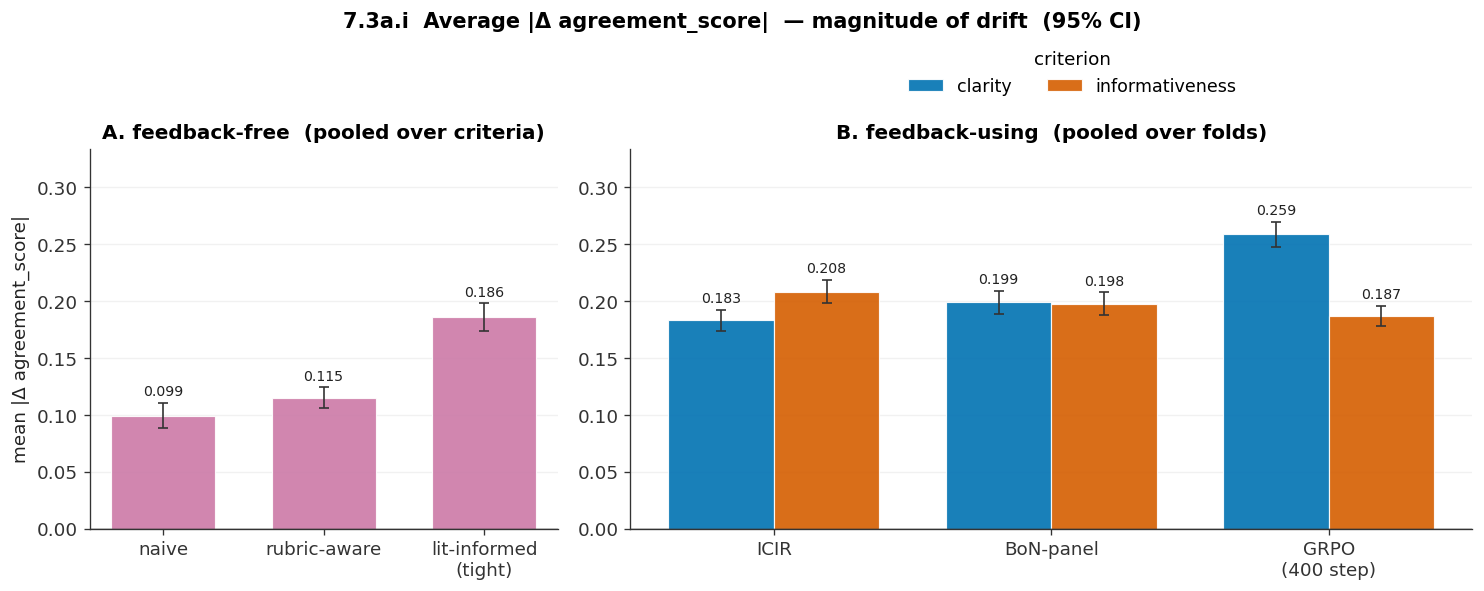

In [19]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8),
                         gridspec_kw={'width_ratios': [1, 1.8]})

# Panel A: feedback-free
axA = axes[0]
sub = abs_ff.set_index('method').reindex(methods_ff)
means = sub['mean'].values
cis = sub['ci95'].values
x = np.arange(len(methods_ff))
bars = axA.bar(x, means, 0.65, yerr=cis, capsize=3,
               color=OKABE_ITO['purple'], alpha=0.9,
               edgecolor='white', linewidth=0.7,
               error_kw={'ecolor': '#333333', 'elinewidth': 1})
_annotate_bars(axA, bars, means, cis, fmt='{:.3f}', pad=0.004)
axA.set_xticks(x)
axA.set_xticklabels([METHOD_TICK[m] for m in methods_ff])
_style_bar_axes(axA,
                ylabel='mean |Δ agreement_score|',
                title='A. feedback-free  (pooled over criteria)')

# Panel B: feedback-using
axB = axes[1]
x = np.arange(len(methods_fu))
width = 0.38
crit_handles = []
for i, crit in enumerate(criteria):
    sub = (abs_fu[abs_fu['criterion'] == crit]
           .set_index('method').reindex(methods_fu))
    means = sub['mean'].values
    cis = sub['ci95'].values
    bars = axB.bar(x + (i - 0.5) * width, means, width,
                   yerr=cis, capsize=3,
                   label=crit, color=CRITERION_COLOR[crit], alpha=0.9,
                   edgecolor='white', linewidth=0.7,
                   error_kw={'ecolor': '#333333', 'elinewidth': 1})
    _annotate_bars(axB, bars, means, cis, fmt='{:.3f}', pad=0.004)
    crit_handles.append(bars)
axB.set_xticks(x)
axB.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
_style_bar_axes(axB, title='B. feedback-using  (pooled over folds)')

ymax = max(axA.get_ylim()[1], axB.get_ylim()[1]) * 1.18
for ax in axes:
    ax.set_ylim(0, ymax)

fig.legend(crit_handles, criteria, title='criterion',
           loc='upper center', bbox_to_anchor=(0.72, 0.98),
           ncol=2, frameon=False, fontsize=10.5)
fig.suptitle('7.3a.i  Average |Δ agreement_score|  — magnitude of drift  (95% CI)',
             y=1.02, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'fig7_3a_abs_shift.png')
plt.show()

##### Signed shift, by proposition leaning

Same methods, but each method now has three bars: pooled (all 714 paragraphs), left-wing propositions only (443), right-wing propositions only (254). "Neither" propositions (17) are excluded from the wing bars but included in pooled. A symmetric y-axis makes positive vs negative drifts visually comparable.

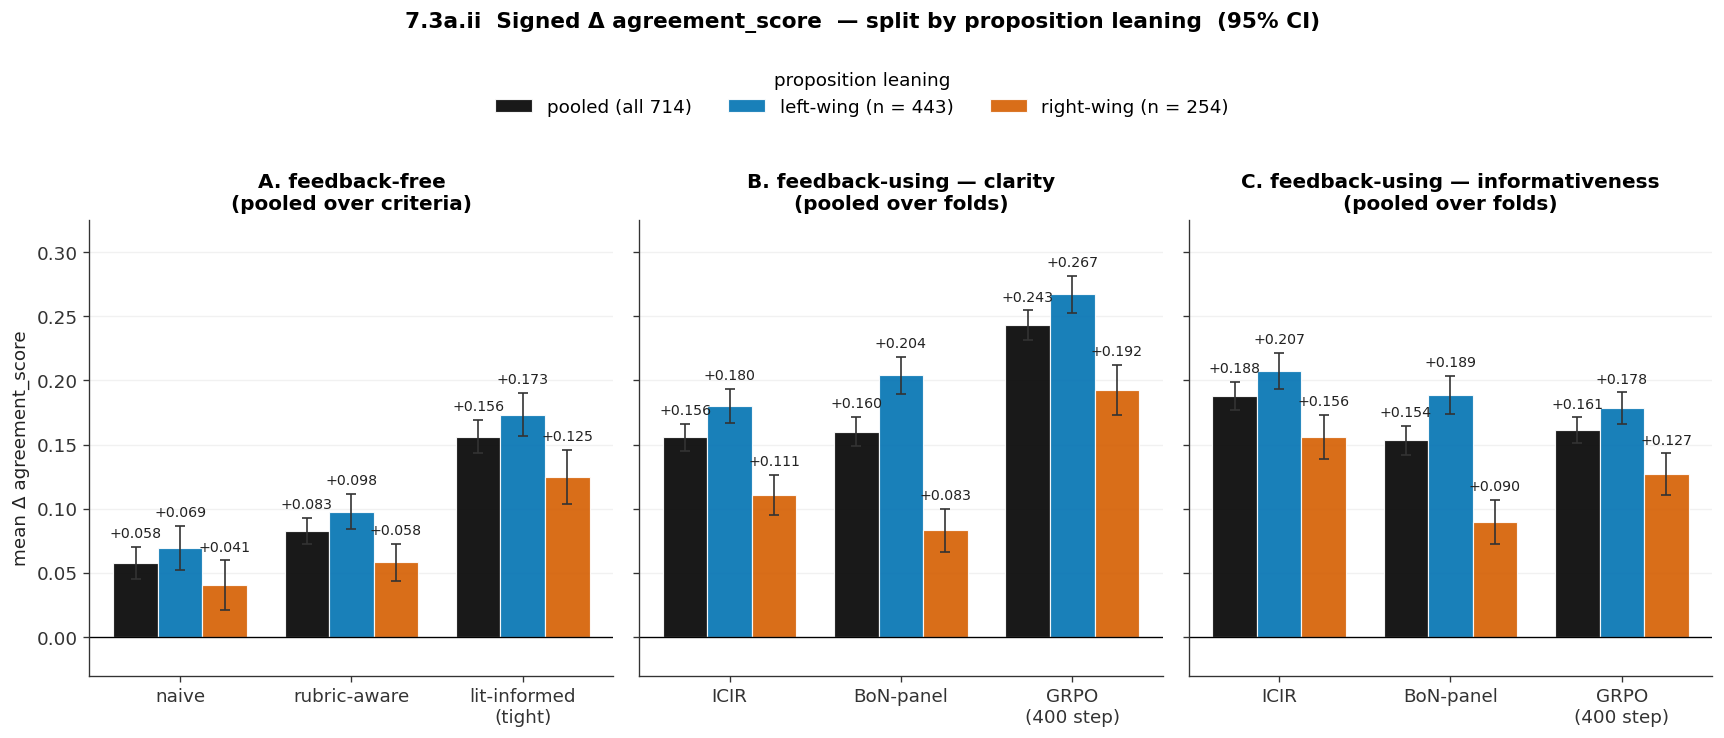

In [20]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
LEANINGS = ['pooled', 'left', 'right']
LEANING_COLOR = {
    'pooled': OKABE_ITO['black'],
    'left': OKABE_ITO['blue'],
    'right': OKABE_ITO['vermilion'],
}
LEANING_LABEL = {
    'pooled': 'pooled (all 714)',
    'left': 'left-wing (n = 443)',
    'right': 'right-wing (n = 254)',
}

fig, axes = plt.subplots(1, 3, figsize=(14.5, 6.0), sharey=True)
axA, axClar, axInf = axes
panel_specs = [
    (axA, 'A. feedback-free\n(pooled over criteria)', signed_ff, methods_ff, None),
    (axClar, 'B. feedback-using — clarity\n(pooled over folds)', signed_fu, methods_fu, 'clarity'),
    (axInf, 'C. feedback-using — informativeness\n(pooled over folds)', signed_fu, methods_fu, 'informativeness'),
]

lean_handles = {}
for ax, title, df, methods, criterion_filter in panel_specs:
    x = np.arange(len(methods))
    width = 0.26
    for i, leaning in enumerate(LEANINGS):
        sub = df[df['leaning'] == leaning].copy()
        if criterion_filter is not None:
            sub = sub[sub['criterion'] == criterion_filter]
        sub = sub.set_index('method').reindex(methods)
        means = sub['mean'].values
        cis = sub['ci95'].values
        bars = ax.bar(x + (i - 1) * width, means, width,
                      yerr=cis, capsize=3,
                      label=LEANING_LABEL[leaning],
                      color=LEANING_COLOR[leaning], alpha=0.9,
                      edgecolor='white', linewidth=0.7,
                      error_kw={'ecolor': '#333333', 'elinewidth': 1})
        _annotate_bars(ax, bars, means, cis, fmt='{:+.3f}', pad=0.005, fontsize=8.5)
        if ax is axA:
            lean_handles[leaning] = bars
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_TICK[m] for m in methods])
    _style_bar_axes(ax,
                    ylabel='mean Δ agreement_score' if ax is axA else None,
                    title=title)

# Asymmetric y-axis: show zero clearly but don't waste vertical space
# on the empty negative region.
ylo = min(ax.get_ylim()[0] for ax in axes)
yhi = max(ax.get_ylim()[1] for ax in axes)
ylo = min(ylo, -0.03)  # ensure zero line is visible with a little slack
yhi = yhi * 1.10
axA.set_ylim(ylo, yhi)

fig.legend([lean_handles[l] for l in LEANINGS],
           [LEANING_LABEL[l] for l in LEANINGS],
           title='proposition leaning',
           loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=3, frameon=False, fontsize=11)
fig.suptitle('7.3a.ii  Signed Δ agreement_score  — split by proposition leaning  (95% CI)',
             y=1.02, fontsize=13, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(FIG_DIR / 'fig7_3a_signed_shift_by_wing.png')
plt.show()

#### 7.3b — Stance-flip rate

% of kept paragraphs (originals with agreement strictly between 0.25 and 0.75 are excluded) whose stance flips. `anti → pro` = rewrite moves from original ≤ 0.25 to rewrite ≥ 0.75; `pro → anti` is the reverse. For feedback-using methods each (paragraph × fold) contributes one observation, so the denominator is 3× the per-fold kept count.

In [21]:
def _flip_summary(g):
    kept = g[g['flip_class'] != 'excluded']
    n_keep = len(kept)
    n_l2h = (kept['flip_class'] == 'flip_low_to_high').sum()
    n_h2l = (kept['flip_class'] == 'flip_high_to_low').sum()
    n_flip = n_l2h + n_h2l
    return pd.Series({
        'pct_flipped': 100 * n_flip / n_keep if n_keep else float('nan'),
        'n_L_to_H': int(n_l2h),
        'n_H_to_L': int(n_h2l),
        'n_kept': int(n_keep),
        'n_excluded': int(len(g) - n_keep),
    })

flip_ff = (agree[agree['method'].isin(FEEDBACK_FREE)]
           .groupby('method').apply(_flip_summary).reset_index())
flip_ff = flip_ff.sort_values('pct_flipped', ascending=False).reset_index(drop=True)
print('Feedback-free — stance-flip rate (pooled across criteria):')
print(flip_ff.round(2).to_string(index=False))

flip_fu = (agree[agree['method'].isin(FEEDBACK_USING)]
           .groupby(['method', 'rewrite_criterion']).apply(_flip_summary).reset_index()
           .rename(columns={'rewrite_criterion': 'criterion'}))
flip_fu = flip_fu.sort_values(['criterion', 'pct_flipped'], ascending=[True, False]).reset_index(drop=True)
print()
print('Feedback-using — stance-flip rate (pooled over folds):')
print(flip_fu.round(2).to_string(index=False))

Feedback-free — stance-flip rate (pooled across criteria):
            method  pct_flipped  n_L_to_H  n_H_to_L  n_kept  n_excluded
lit_informed_tight        13.23     133.0       3.0  1028.0       400.0
      rubric_aware         6.23      64.0       0.0  1028.0       400.0
             naive         3.11      16.0       0.0   514.0       200.0

Feedback-using — stance-flip rate (pooled over folds):
      method       criterion  pct_flipped  n_L_to_H  n_H_to_L  n_kept  n_excluded
grpo_400step         clarity        20.56     310.0       7.0  1542.0       600.0
   bon_panel         clarity        14.53     215.0       9.0  1542.0       600.0
        icir         clarity        11.93     182.0       2.0  1542.0       600.0
        icir informativeness        15.05     230.0       2.0  1542.0       600.0
   bon_panel informativeness        14.59     212.0      13.0  1542.0       600.0
grpo_400step informativeness         9.99     149.0       5.0  1542.0       600.0


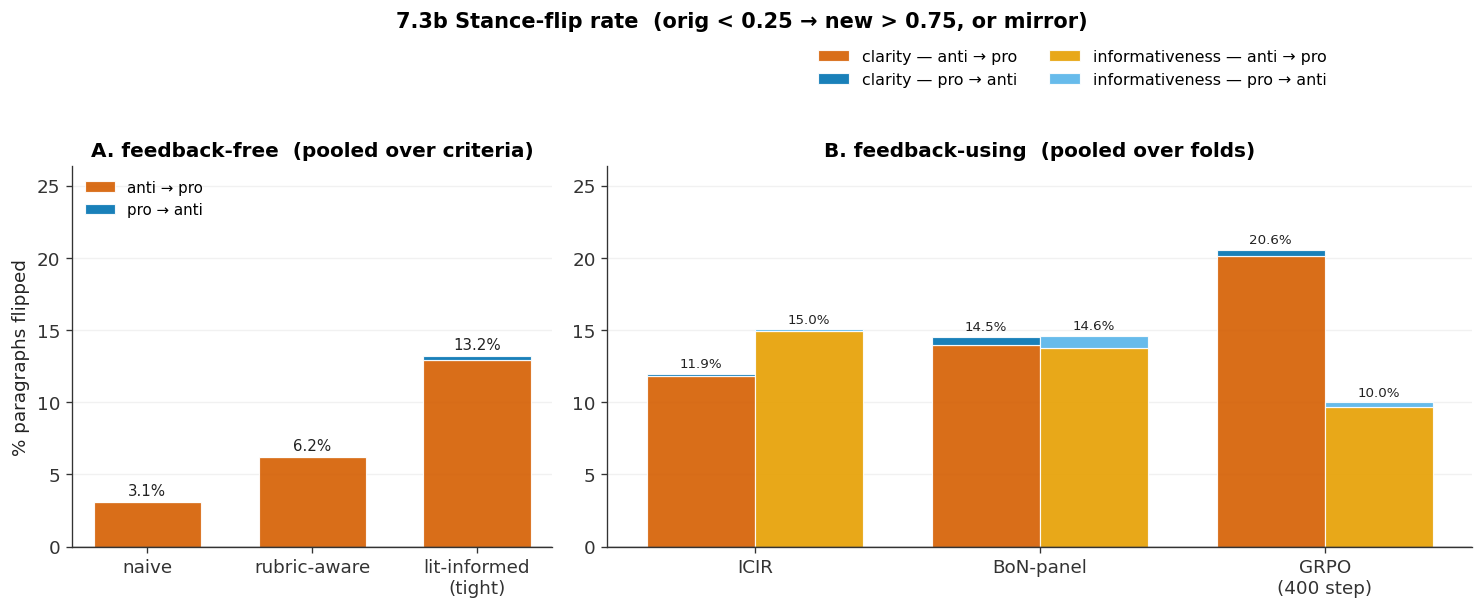

In [22]:
methods_ff = ['naive', 'rubric_aware', 'lit_informed_tight']
methods_fu = ['icir', 'bon_panel', 'grpo_400step']
criteria = ['clarity', 'informativeness']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9),
                         gridspec_kw={'width_ratios': [1, 1.8]})

# Panel A.
axA = axes[0]
sub = flip_ff.set_index('method').reindex(methods_ff)
x = np.arange(len(methods_ff))
n_keep = sub['n_kept'].values
pct_L2H = 100 * sub['n_L_to_H'].values / n_keep
pct_H2L = 100 * sub['n_H_to_L'].values / n_keep
ff_L2H = axA.bar(x, pct_L2H, 0.65, color=OKABE_ITO['vermilion'], alpha=0.9,
                 edgecolor='white', linewidth=0.7, label='anti → pro')
ff_H2L = axA.bar(x, pct_H2L, 0.65, bottom=pct_L2H, color=OKABE_ITO['blue'], alpha=0.9,
                 edgecolor='white', linewidth=0.7, label='pro → anti')
for xi, total in zip(x, pct_L2H + pct_H2L):
    axA.text(xi, total + 0.25, f'{total:.1f}%', ha='center', va='bottom',
             fontsize=9, color='#222222')
axA.set_xticks(x)
axA.set_xticklabels([METHOD_TICK[m] for m in methods_ff])
_style_bar_axes(axA,
                ylabel='% paragraphs flipped',
                title='A. feedback-free  (pooled over criteria)')

# Panel B.
axB = axes[1]
x = np.arange(len(methods_fu))
width = 0.38
colour_L2H = {'clarity': OKABE_ITO['vermilion'], 'informativeness': OKABE_ITO['orange']}
colour_H2L = {'clarity': OKABE_ITO['blue'], 'informativeness': OKABE_ITO['sky']}
legend_handles = []
legend_labels = []
for i, crit in enumerate(criteria):
    sub = (flip_fu[flip_fu['criterion'] == crit]
           .set_index('method').reindex(methods_fu))
    n_keep = sub['n_kept'].values
    pct_L2H = 100 * sub['n_L_to_H'].values / n_keep
    pct_H2L = 100 * sub['n_H_to_L'].values / n_keep
    offset = (i - 0.5) * width
    bL = axB.bar(x + offset, pct_L2H, width, color=colour_L2H[crit], alpha=0.9,
                 edgecolor='white', linewidth=0.7)
    bH = axB.bar(x + offset, pct_H2L, width, bottom=pct_L2H,
                 color=colour_H2L[crit], alpha=0.9,
                 edgecolor='white', linewidth=0.7)
    legend_handles += [bL, bH]
    legend_labels += [f'{crit} — anti → pro', f'{crit} — pro → anti']
    for xi, total in zip(x + offset, pct_L2H + pct_H2L):
        axB.text(xi, total + 0.25, f'{total:.1f}%', ha='center', va='bottom',
                 fontsize=8, color='#222222')

axB.set_xticks(x)
axB.set_xticklabels([METHOD_TICK[m] for m in methods_fu])
_style_bar_axes(axB,
                title='B. feedback-using  (pooled over folds)')

ymax = max(axA.get_ylim()[1], axB.get_ylim()[1]) * 1.22
for ax in axes:
    ax.set_ylim(0, ymax)

# Composite legend above panels.
axA.legend(loc='upper left', frameon=False, fontsize=9)
fig.legend(legend_handles, legend_labels,
           loc='upper center', bbox_to_anchor=(0.72, 0.99),
           ncol=2, frameon=False, fontsize=9.5)
fig.suptitle('7.3b Stance-flip rate  (orig < 0.25 → new > 0.75, or mirror)',
             y=1.03, fontsize=12.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.91])
fig.savefig(FIG_DIR / 'fig7_3b_stance_flip.png')
plt.show()

In [23]:
conn.close()